# Autoestudio 7 - Caminos más cortos

Al finalizar este autoestudio debe adquirir conocimiento para:

1. Discutir acerca del problema de caminios óptimos
2. Comprender los dos algoritmos clásicos de de búsqueda de camino óptimo
3. Proponer una implementación alternativa para un grafo con pesos

In [ ]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = 0 # @param {"type":"integer"}


## Caminos más cortos

Es común encontrar situaciones en la vida cotidiana en donde queremos conocer el camino óptimo para llegar de un punto $A$ a un punto $B$.

El camino óptimo dependera mucho de lo que queramos optimizar.
- ¿Queremos tomar el camino más corto?
- ¿Queremos tomar el camino más económico en terminos de combustible?
- ¿Queremos tomar el camino que menos peajes tenga?
- ¿Queremos tomar el camino que nos tome menos tiempo en llegar? (no siempre el camino más corto es el más rapido en una ciudad, tome como referencia el trafico de Bogota).
- etc...

Queremos poder optimizar nuestra ruta segun el criterio que escojamos. Para establecer este criterio usualmente es necesario establecer un criterio numerico por el que podemos optimizar.
El caso más común en el que podriamos pensar es en el de minimizar distancia recorrida.

## Grafos con pesos

En el contexto de algoritmos y tomando en cuenta lo que ya hemos visto en el curso. Podemos establer que para un grafo que tengamos $G = (V, E)$, tambien definiremos una función que nos dara un valor numerico de nuestros arcos, tal y como se establecer en el libro guia, este se establecer como una función $w$:
$$
  w\ :\ E \to \mathbb{R}
$$
donde esta función recibe un arco de nuestro grafo $(u, v) \in E$, y nos da como respuesta un valor numerico en los reales $\mathbb{R}$.

En el contexto de el camino más corto en nuestro ejemplo, la función $w$ representa la distancia desde el punto $u$ al punto $v$ en el grafo.

## ¿Cómo representamos un grafo con pesos?

Volviendo a nuestra representaciones de autoestudios anteriores, podemos representar grafos con:
- Listas de adyacencia
- Matriz de adyacencia

Para propósitos demostrativos, vamos a implementar la representacion de lista de adyacencia con pesos.

Nuestro grafo sigue siendo una lista de listas de elementos `list[list[Edge]]`, donde cada fila corresponde a cada vértice origen $u$ , y cada elemento de esa fila es un vértice $v$ destino.

Pero, en esta ocasion tambien definiremos nuestra conexion a $u$, como una tupla del costo y el vértice destino $(w_{u\to v}, v)$, donde $w_{u\to v}$ es el costo de ir desde $u$ hacia $v$.

Con esto en mente, definimos a cada elemento de la lista de adyacencia como `Edge = tuple[float, int]`.

In [ ]:
Edge = tuple[float, int]
Graph = list[list[Edge]]

De manera que si queremos representar el siguiente grafo, basta con tener lo siguiente:

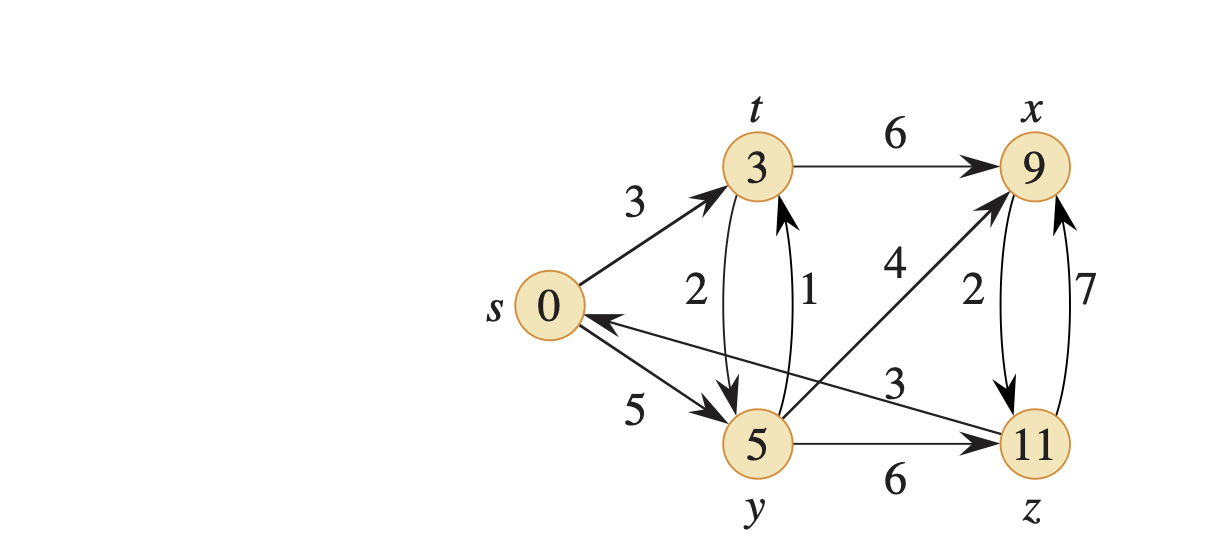

In [ ]:
n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
    (s, t, 3),
    (s, y, 5),
    (t, x, 6),
    (t, y, 2),
    (y, t, 1),
    (y, x, 4),
    (y, z, 6),
    (x, z, 2),
    (z, x, 7),
    (z, s, 3),
]

for u, v, w in edges:
  G[u].append((w, v))

In [ ]:
# Veamos la representacion

for u, adj in enumerate(G):
  print(f"{u} -> {adj}")

0 -> [(3, 1), (5, 2)]
1 -> [(6, 3), (2, 2)]
2 -> [(1, 1), (4, 3), (6, 4)]
3 -> [(2, 4)]
4 -> [(7, 3), (3, 0)]


### Grafiquemos

Ahora, queremos poder ver nuestra representacion de grafo visualmente, para esto usaremos la función `draw`.

In [ ]:
# @title Ejecute esta celda para definir el metodo `draw`

import graphviz as gv
from typing import Any

def draw(G: Graph):
  dot = gv.Digraph()
  dot.strict = True
  dot.attr(bgcolor='lightgray', rankdir="LR")

  default_metadata = {
    "fillcolor": 'white',
    "fontcolor": 'black',
    "style": "filled",
    "shape": "circle",
  }

  n = len(G)
  for u, adj in enumerate(G):
    meta = default_metadata
    dot.node(str(u), **meta)
    for w, v in adj:
      dot.edge(str(u), str(v), label=str(w))

  return dot

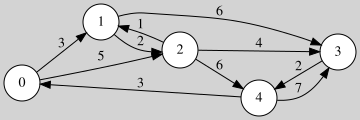

In [ ]:
draw(G)

### $\color{blue}{Ejercicios}$

1. **Implemente** la representacion de grafo con pesos en una matriz de adyacencia. ¿Que debe guardar en cada entrada $A_{i,j}$ de la matriz?

In [ ]:
# Implemente

----

## Caminos en un grafo

Un camino _simple_ lo podemos definir como una secuencia de vértices en nuestro grafo $p$:
$$
  p = \langle v_0, v_1, \ldots, v_k \rangle
$$
donde la secuencia de vértices coinciden con las conexiones de nuestro grafo, es decir, es un camino que podemos seguir en orden secuencial. (i.e. para cualquier $i \in \{1, \ldots, k\}$, tenemos $(v_{i-1}, v_i) \in E$).

La razón de por que lo llamamos *simple* es por que ningun vértice se repite en el camino $p$. (i.e. $v_i \neq v_j$ para cualquier $i \neq j$).

Ahora, podemos también definir el peso de nuestro camino usando nuestra función $w$, teniendo:
$$
  w(p) = \sum_{i=1}^{k} w(v_{i-1}, v_i)
$$

O bien, la suma de los pesos de cada una de las aristas que conforman nuestro camino $p$.

## Caminos mínimos en un grafo

Ahora volviendo a lo que queremos resolver en nuestro grafo, queremos conseguir el camino óptimo considerando los costos de cada camino $p$ posible. Adicionalmente, queremos poder calcularlo desde un punto de partida, que lo llamaremos $s$.

Queremos calcular un camino que tenga el costo mínimo, y que vaya desde $u \in V$ a cualquier otro vértice $v\in V$ dentro de nuestro grafo (siempre y cuando este sea alcanzable). Lo definimos como

$$
  \delta(u, v) = \begin{cases}
   \min_p \{w(p) \,:\, u \overset{p}{\leadsto} v\} & \text{si existe un camino desde } u \text{ hasta } v \\
   \infty & \text{sino} \\
  \end{cases}
$$

que determina el valor del camino que tiene el menor peso si $v$ es alcanzable desde $u$. De no ser asi decimos que su distancia es $\infty$.

Ahora, ¿Cómo podemos nosotros determinar cual es ese camino que minimiza los pesos para llegar desde $u$ a $v$? Vamos a ver dos algoritmos que determinan esto:
 - Bellman Ford
 - Dijkstra

Ambos determinan el camino mínimo desde una **fuente** $s\in V$ hacia cualquiera de los otros nodos alcanzables de nuestro grafo ($v\in V-\{s\}$).

### Relajación

Un concepto clave que comparten ambos de estos algoritmos es el concepto de relajación.

Definamos los atributos que necesitaremos, para cada vértice $u\in V$ debemos tener:
 - $v.d$ (`distance`) que se define como la distancia del camino más corto conocido desde nuestra fuente $s$ (i.e. $v.d = \delta(\langle s, \ldots, v \rangle)$).
 - $v.\pi$ (`pred`) que define el nodo _predecesor_ en nuestro camino mínimo conocido (i.e. $p = \langle s, \ldots, v.\pi.\pi, v.\pi, v, \ldots \rangle$).

En nuestros algoritmos existe una fase de inicialización que establece que todos los vértices de nuestro grafo tendran el valor de $v.d = \infty$ y $v.\pi = \text{NIL}$. Es decir, asumimos que nada es alcanzable inicialmente.

Para nuestro nodo fuente $s$, tendriamos $s.d = 0$.

El proceso de relajación (`relax`) para una arista $(u, v) \in E$ consiste en verificar si ir por el nodo $u$ mejora el camino más corto de $v$ que se ha encontrado hasta ese momento. De ser asi, entonces actualice $v.d = u.d + w(u, v)$ y actualice $v.\pi = u$.

## Bellman-Ford

El algoritmo de Bellman-Ford resuelve el problema de caminos cortos desde una fuente para el caso general en la los pesos de nuestras conexiones pueden ser **negativos**. Y adicionalmente nos permite detectar si existe algun _ciclo negativo_ dentro de nuestro grafo.

Este opera en tres partes:
1. Inicialización de los vértices.
2. Relajación de todos los arcos de grafo, hacemos esto $\lvert V \rvert -1$ veces.
3. Verificación de la existencia de algun ciclo negativo.

Para implementar el algoritmo podriamos optar por una de dos alternativas:
1. Implementar nuestro objeto en Python de nodo que guarde los atributos de `distance` y `pred` para cada vértice.
2. Utilizar una lista de distancias y otra lista de predecesores, donde ambas listas tienen $\lvert V \rvert$ elementos y donde la $i$-esimas entrada corresponde al $i$-esimo vértice de nuestro grafo.

**_Lo haremos con la segunda opcion._**

In [ ]:
def relax(dist: list[float], preds: list[int | None], u: int, v: int, w: float):
  if dist[v] > dist[u] + w:
    dist[v] = dist[u] + w
    preds[v] = u
    # Retornamos True si la relajación hizo una modificacion
    return True

  return False

In [ ]:
def bellman_ford(G: Graph, s: int):
  INFTY = 2**64 # Valor simbolico de infinito, un valor suficientemente grande

  # 1. Inicialización
  n = len(G)
  # inicialmente ningun nodo tiene predecesor
  preds: list[int | None] = [None for _ in range(n)]
  # asumimos que ningun nodo es alcanzable inicialmente
  dist: list[float] = [INFTY for _ in range(n)]
  dist[s] = 0.0 # a excepcion de la fuente

  # 2. Relajamos todos las aristas del grafo |V| - 1 veces
  for _ in range(n - 1):
    for u in range(n):
      for w, v in G[u]:
        relax(dist, preds, u, v, w)

  # 3. Verificamos si existen ciclos negativos
  for u in range(n):
    for w, v in G[u]:
      if dist[v] > dist[u] + w:
        return dist, preds, False

  return dist, preds, True

Con esto definido, verifiquemos visualmente los caminos mínimos que se calculan con `bellman_ford`.

Para esto usaremos la función `draw_sssp`, que recibe como parametros nuestro grafo, con pesos, la lista de distancias de los vértices y la lista de predecesores de cada vértice.

In [ ]:
# @title Ejecute esta celda para definir el metodo `draw_sssp`

import graphviz as gv
from typing import Any

def draw_sssp(G: Graph, dist: list[float], preds: list[int | None]):
  assert isinstance(dist, list), "se espera una lista de distancias"
  assert all(isinstance(v, int | float) for v in dist), "se espera que la lista de distancia sean números"
  assert isinstance(preds, list), "se espera una lista de predecesores"
  assert all(isinstance(v, int | None) for v in preds),"se espera una lista de predecesores con números o None"

  dot = gv.Digraph()
  dot.strict = True
  dot.attr(bgcolor='lightgray', rankdir="LR")

  default_metadata = {
    "fillcolor": 'white',
    "fontcolor": 'black',
    "style": "filled",
    "shape": "circle",
  }

  n = len(G)
  for u, adj in enumerate(G):
    meta = default_metadata
    dot.node(
        str(u),
        xlabel=f"[{dist[u]}]",
        **meta)
    for w, v in adj:
      if preds[v] == u:
        dot.edge(str(u), str(v), label=str(w), color="red")
      else:
        dot.edge(str(u), str(v), label=str(w))

  return dot

In [ ]:
# Volvamos a definir el mismo grafo que arriba

n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
    (s, t, 3),
    (s, y, 5),
    (t, x, 6),
    (t, y, 2),
    (y, t, 1),
    (y, x, 4),
    (y, z, 6),
    (x, z, 2),
    (z, x, 7),
    (z, s, 3),
]

for u, v, w in edges:
  G[u].append((w, v))

NO tiene ciclos negativos? True


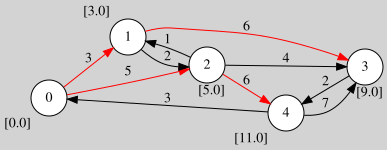

In [ ]:
dist, preds, no_negative_cycles = bellman_ford(G, s)
print("NO tiene ciclos negativos?", no_negative_cycles)
draw_sssp(G, dist, preds)

Aqui podemos observar que el algoritmo no sólo calculó el camino mínimo para cada uno de los vértices (marcados en $\color{red}{rojo}$) dentro del grafo desde $s=0$, donde el costo del camino para llegar a cada uno esta denotado como $[u.d]$ para cada $u\in V$.

Ahora usemos otro grafo, uno que tenga pesos negativos.

In [ ]:
n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
  (s, t, 6),
  (s, y, 7),
  (t, x, 5),
  (t, z, -4),
  (t, y, 8),
  (y, x, -3),
  (y, z, 9),
  (x, t, -2),
  (z, s, 2),
]

for u, v, w in edges:
  G[u].append((w, v))

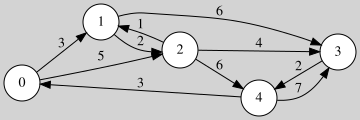

In [ ]:
draw(G)

Ahora calculemos los caminos mínimos desde $s=0$ y determinemos si contiene ciclos negativos.

NO tiene ciclos negativos? True


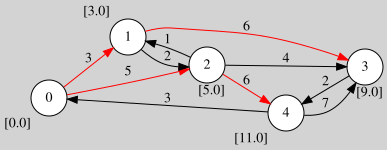

In [ ]:
dist, preds, no_negative_cycle = bellman_ford(G, s)
print("NO tiene ciclos negativos?", no_negative_cycle)
draw_sssp(G, dist, preds)

Nótese que el grafo, a pesar de tener valores negativos, no tiene ciclos negativos.

La presencia de un ciclo negativo implicaria que no existiria camino mínimo válido: podriamos seguir por ese camino infinitamente y diverger a $-\infty$.

----

Ahora hagamos un cambio en nuestro grafo de manera que solo vamos a modificar un solo arco: $z \to s$ que tiene valor de $2$, vamos a cambiar ese valor a $1$ y veamos que ocurre.

In [ ]:
n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
  (s, t, 6),
  (s, y, 7),
  (t, x, 5),
  (t, z, -4),
  (t, y, 8),
  (y, x, -3),
  (y, z, 9),
  (x, t, -2),
  (z, s, 1), # <<<<< solo hicimos cambio aqui
]

for u, v, w in edges:
  G[u].append((w, v))

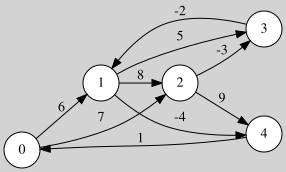

In [ ]:
draw(G)

NO tiene ciclos negativos? False


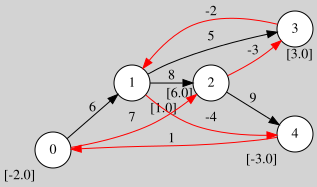

In [ ]:
dist, preds, no_negative_cycle = bellman_ford(G, s)
print("NO tiene ciclos negativos?", no_negative_cycle)
draw_sssp(G, dist, preds)

Nótese dos cosas, el nuevo costo para llegar de $s$ es $s.d = -2$, y nuestro metodo devuelve `False` ante la presencia de un ciclo negativo. más aun, se puede observar cual es el arco que forma ese ciclo negativo: el arco $4 \to 0$ esta marcado en rojo.

Podemos asumir que los costos calculados no son representativos del camino mínimo, debido a que para reducir el costo de nuestro camino solo basta con seguir el ciclo infinitamente.

### $\color{blue}{Ejercicios}$

1. **Implemente** la función `get_min_path`, que dado un grafo $G$ y la salida de nuestro algoritmo de caminos mínimos (`dist` y `preds`), reconstruya el camino mínimo para llegar a alguno de los vértices dados $v\in V$.

In [ ]:
def get_min_path(G, dist, preds, v) -> list[int]:
  n = len(G)
  assert 0 <= v < n, "el nodo debe estar entre los vértices de nuestro grafo G"

  # Implemente
  return []

Ensaye su implementacion con el siguiente grafo.


In [ ]:
n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
  (s, t, 6),
  (s, y, 7),
  (t, x, 5),
  (t, z, -4),
  (t, y, 8),
  (y, x, -3),
  (y, z, 9),
  (x, t, -2),
  (z, s, 2),
]

for u, v, w in edges:
  G[u].append((w, v))

In [ ]:
dist, preds, no_negative_cycle = bellman_ford(G, s)

print("V =", [i for i in range(len(G))])
print("dist = ",dist)
print("preds =", preds)
print()

def test(G, dist, preds, v, expected):
  res = get_min_path(G, dist, preds, v)
  if res != expected:
    print(f"Se esperaba {expected}, se obtuvo {res}")
  else:
    print("Paso prueba")

test(G, dist, preds, s, [s])
test(G, dist, preds, t, [s, y, x, t])
test(G, dist, preds, x, [s, y, x])
test(G, dist, preds, y, [s, y])
test(G, dist, preds, z, [s, y, x, t, z])

V = [0, 1, 2, 3, 4]
dist =  [0.0, 2.0, 7.0, 4.0, -2.0]
preds = [None, 3, 0, 2, 1]

Se esperaba [0], se obtuvo []
Se esperaba [0, 2, 3, 1], se obtuvo []
Se esperaba [0, 2, 3], se obtuvo []
Se esperaba [0, 2], se obtuvo []
Se esperaba [0, 2, 3, 1, 4], se obtuvo []


----

## Algoritmo de Dijkstra

Un algoritmo más eficiente para resolver el problema del camino más corto desde una fuente (SSSP) es el algoritmo de Dijkstra.

A diferencia de Bellman-Ford que hace el calculo de los caminos mínimos de manera _voraz_ (realiza relajación de todos los arcos sin ninguna estrategia), este algoritmo realiza la relajación de cada arco priorizando su procesamiento con ayuda de una **cola de prioridad minimal**.

Mientras que Bellman-Ford calcula los caminos en tiempo $O(VE)$, este lo resuelve en $O(V^2)$, que dependiendo de la implementacion de la cola de prioridad puede mejorar a $O(E \log V)$.

**¿Entonces por qué no usamos Dijkstra para SSSP en vez de Bellman-Ford?**

El algoritmo de Dijkstra tiene como precondición que **ninguno** de los pesos de nuestro grafo sea negativo.

Definamos ahora nuestro algoritmo, reutilizaremos el metodo `relax` que usamos en la seccion anterior. Pero implementaremos nuestra version de cola de prioridad con un monton binario.

Usaremos la implementacion nativa de Python de la libreria `heapq`.

In [ ]:
import heapq

# Tambien podemos usar heapq directamente, pero lo usamos para propósitos ilustrativos

class MinPriorityQueue:
  def __init__(self):
    self.heap = []

  def insert(self, v):
    heapq.heappush(self.heap, v)

  def extract_min(self):
    assert len(self.heap) > 0, "el monton esta vacío"
    return heapq.heappop(self.heap)

  def minimum(self):
    assert len(self.heap) > 0
    return self.heap[0]

  def is_empty(self) -> bool:
    return len(self.heap) == 0

In [ ]:
def dijkstra(G: Graph, s: int):
  INFTY = 2**64
  # 1. Inicialización (la misma que en Bellman-Ford)
  n = len(G)
  preds: list[int | None] = [None for _ in range(n)]
  dist: list[float] = [INFTY for _ in range(n)]
  dist[s] = 0.0

  # Creamos nuestra cola de prioridad
  pq = MinPriorityQueue()
  # Insertamos todos los vértices en la cola de prioridad con los pesos de los arcos
  for u in range(n):
    pq.insert((dist[u], u)) # insertamos la tupla (w, u)

  # Empezamos la iteracion sobre nuestra cola de prioridad
  while not pq.is_empty():
    # extraemos el elemento que tiene menor peso en nuestra cola de prioridad
    _, u = pq.extract_min()
    for w, v in G[u]:
      is_relaxed = relax(dist, preds, u, v, w)
      if is_relaxed:
        pq.insert((dist[v], v))

  return dist, preds


Ahora utilicemos nuestro algoritmo para calcula las rutas minimas de el siguiente grafo:

In [ ]:
n = 5
# inicialmente un grafo vacío
G: Graph = [[] for _ in range(n)]

# coloquemos números a cada vértice
s, t, y, x, z = 0, 1, 2, 3, 4

edges = [
  # (u, v, w)
    (s, t, 10),
    (s, y, 5),
    (t, x, 1),
    (t, y, 2),
    (y, t, 3),
    (y, x, 9),
    (y, z, 2),
    (x, z, 4),
    (z, x, 6),
    (z, s, 7),
]

for u, v, w in edges:
  G[u].append((w, v))

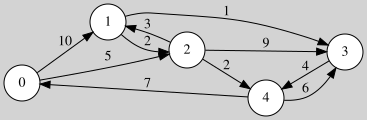

In [ ]:
draw(G)

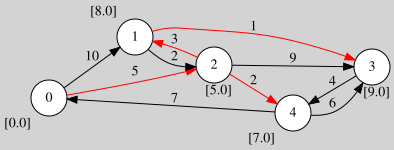

In [ ]:
dist, preds = dijkstra(G, s)

draw_sssp(G, dist, preds)

### $\color{blue}{Ejercicios}$

1. Note que estamos usando tuplas de la forma $(a, b)$ en nuestra cola de prioridad como elementos. Internamente se estan haciendo comparaciones de la forma $(a, b) < (c, d)$ para garantizar la propiedad de monton binario minimal de $A[\text{Parent}(i)] \leq A[i]$ para todo $i \in \{2, \ldots, \text{heap-size}\}$. **Investigue** que hace Python internamente al realizar las siguientes operaciones:

In [ ]:
print((1, 2) < (2, 3))
print((1, 2) < (1, 3))
print((1, 2) < (1, 2))
print((1, 1) < (2, 1))

True
True
False
True


2. Note que los elementos que agregamos a nuestra cola de prioridad son tuplas de la forma $(v.d, v)$, donde $v.d$ es el peso del camino más corto conocido para llegar a $v$ desde $s$ y $v$ es el vértice destino de nuestro arco.

**Argumente** si el orden de los elementos en nuestra tupla importa, ¿Al agregar $(v, v.d)$ en vez de $(v.d, v)$ se obtendra el mismo efecto sobre el resultado del algoritmo? Ilustre un ejemplo de como funcionaria uno versus el otro, puede ser en codigo usando nuestra implementacion de `MinPriorityQueue`.

3. (**Bono+**) Note en nuestra implementacion de Dijkstra que en la linea `22` donde se encuentra `pq.insert((dist[v], v))`, lo que deberia ocurrir para que nuestra implementacion sea eficiente es que en vez de agregar un nuevo elemento a nuestra cola de prioridad, nosotros debemos realizar en realidad una actualizacion de la forma `pq.decrease_key(pos_v, dist[v])`, donde `pos_v` es la posicion del vértice `v` en nuestra cola de prioridad.

Si determinaramos la posicion de `v` de manera ingenua, nos costaria tiempo $O(n)$ por cada vez que la determinemos.

Esta sola diferencia es la que nos permite tener una complejidad de $O(E \log V)$ versus $O(V^2)$.

**Argumente** que cambio deberiamos realizar en nuestra implementacion de cola de prioridad `MinPriorityQueue` para lograr hacer esta operacion de obtener `pos_v` en tiempo aproximado $O(1)$.

----